In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

In [2]:
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

df = pd.read_csv(DATA_PROCESSED / "elliptic_clean.csv")

print("Dataset shape:", df.shape)

Dataset shape: (46564, 168)


In [3]:
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

df = pd.read_csv(DATA_PROCESSED / "elliptic_clean.csv")

print("Dataset shape:", df.shape)

Dataset shape: (46564, 168)


In [4]:
X = df.drop(columns=["label", "txId"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (46564, 166)
y shape: (46564,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (37251, 166)
Test shape: (9313, 166)


In [6]:
rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train, y_train)

clean_pred = rf_clean.predict(X_test)
clean_prob = rf_clean.predict_proba(X_test)[:, 1]

clean_precision = precision_score(y_test, clean_pred)
clean_recall = recall_score(y_test, clean_pred)
clean_f1 = f1_score(y_test, clean_pred)
clean_pr_auc = average_precision_score(y_test, clean_prob)

clean_cm = confusion_matrix(y_test, clean_pred)
_, clean_fp, clean_fn, _ = clean_cm.ravel()

clean_risk = 5 * clean_fn + clean_fp

print("Baseline Recall:", clean_recall)
print("Baseline F1:", clean_f1)
print("Baseline PR-AUC:", clean_pr_auc)
print("Baseline Risk:", clean_risk)

Baseline Recall: 0.8756875687568757
Baseline F1: 0.9326303456356181
Baseline PR-AUC: 0.9800008914718656
Baseline Risk: 567


In [7]:
rf_clean = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train, y_train)

clean_pred = rf_clean.predict(X_test)
clean_prob = rf_clean.predict_proba(X_test)[:, 1]

clean_precision = precision_score(y_test, clean_pred)
clean_recall = recall_score(y_test, clean_pred)
clean_f1 = f1_score(y_test, clean_pred)
clean_pr_auc = average_precision_score(y_test, clean_prob)

clean_cm = confusion_matrix(y_test, clean_pred)
_, clean_fp, clean_fn, _ = clean_cm.ravel()

clean_risk = 5 * clean_fn + clean_fp

print("Baseline Recall:", clean_recall)
print("Baseline F1:", clean_f1)
print("Baseline PR-AUC:", clean_pr_auc)
print("Baseline Risk:", clean_risk)

Baseline Recall: 0.8756875687568757
Baseline F1: 0.9326303456356181
Baseline PR-AUC: 0.9800008914718656
Baseline Risk: 567


In [8]:
def flip_illicit_labels(y_series, flip_ratio=0.10, random_state=42):
    y_flipped = y_series.copy()

    rng = np.random.default_rng(random_state)

    illicit_indices = y_flipped[y_flipped == 1].index
    n_flip = int(len(illicit_indices) * flip_ratio)

    flip_indices = rng.choice(illicit_indices, size=n_flip, replace=False)

    y_flipped.loc[flip_indices] = 0

    return y_flipped, flip_indices

In [9]:
poison_rates = [0.05, 0.10, 0.20, 0.30]

results = []

for rate in poison_rates:
    y_train_poisoned, flipped_indices = flip_illicit_labels(
        y_train,
        flip_ratio=rate,
        random_state=42
    )

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train_poisoned)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    pr_auc = average_precision_score(y_test, prob)

    cm = confusion_matrix(y_test, pred)
    _, fp, fn, _ = cm.ravel()

    risk = 5 * fn + fp

    results.append({
        "Poison Rate": int(rate * 100),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "PR-AUC": pr_auc,
        "False Positives": fp,
        "False Negatives": fn,
        "Compliance Risk": risk
    })

stealth_damage_df = pd.DataFrame(results)
stealth_damage_df

,Poison Rate,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives,Compliance Risk
0,5,0.997468,0.866887,0.927604,0.978666,2,121,607
1,10,0.998703,0.847085,0.916667,0.979346,1,139,696
2,20,1.000000,0.814081,0.897514,0.975941,0,169,845
3,30,0.998437,0.702970,0.825048,0.973395,1,270,1351


In [10]:
stealth_damage_df["Recall Drop"] = clean_recall - stealth_damage_df["Recall"]
stealth_damage_df["F1 Drop"] = clean_f1 - stealth_damage_df["F1 Score"]
stealth_damage_df["PR-AUC Drop"] = clean_pr_auc - stealth_damage_df["PR-AUC"]
stealth_damage_df["Risk Increase"] = stealth_damage_df["Compliance Risk"] - clean_risk

stealth_damage_df

,Poison Rate,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives,Compliance Risk,Recall Drop,F1 Drop,PR-AUC Drop,Risk Increase
0,5,0.997468,0.866887,0.927604,0.978666,2,121,607,0.008801,0.005026,0.001335,40
1,10,0.998703,0.847085,0.916667,0.979346,1,139,696,0.028603,0.015964,0.000655,129
2,20,1.000000,0.814081,0.897514,0.975941,0,169,845,0.061606,0.035117,0.004060,278
3,30,0.998437,0.702970,0.825048,0.973395,1,270,1351,0.172717,0.107582,0.006606,784


In [11]:
stealth_damage_df["Recall Drop"] = clean_recall - stealth_damage_df["Recall"]
stealth_damage_df["F1 Drop"] = clean_f1 - stealth_damage_df["F1 Score"]
stealth_damage_df["PR-AUC Drop"] = clean_pr_auc - stealth_damage_df["PR-AUC"]
stealth_damage_df["Risk Increase"] = stealth_damage_df["Compliance Risk"] - clean_risk

stealth_damage_df

,Poison Rate,Precision,Recall,F1 Score,PR-AUC,False Positives,False Negatives,Compliance Risk,Recall Drop,F1 Drop,PR-AUC Drop,Risk Increase
0,5,0.997468,0.866887,0.927604,0.978666,2,121,607,0.008801,0.005026,0.001335,40
1,10,0.998703,0.847085,0.916667,0.979346,1,139,696,0.028603,0.015964,0.000655,129
2,20,1.000000,0.814081,0.897514,0.975941,0,169,845,0.061606,0.035117,0.004060,278
3,30,0.998437,0.702970,0.825048,0.973395,1,270,1351,0.172717,0.107582,0.006606,784


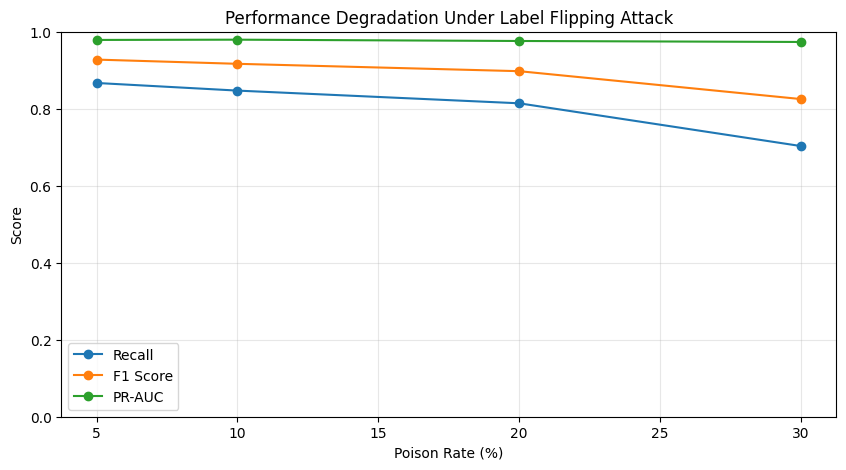

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(stealth_damage_df["Poison Rate"], stealth_damage_df["Recall"], marker="o", label="Recall")
plt.plot(stealth_damage_df["Poison Rate"], stealth_damage_df["F1 Score"], marker="o", label="F1 Score")
plt.plot(stealth_damage_df["Poison Rate"], stealth_damage_df["PR-AUC"], marker="o", label="PR-AUC")

plt.xlabel("Poison Rate (%)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance Degradation Under Label Flipping Attack")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

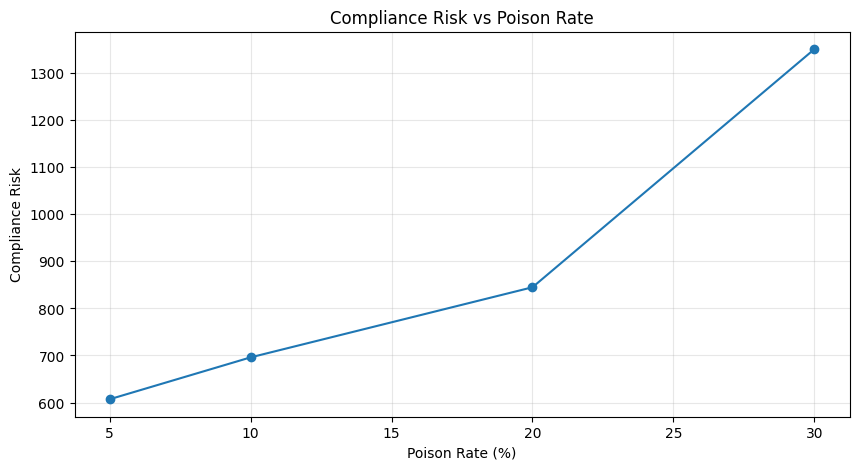

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(stealth_damage_df["Poison Rate"], stealth_damage_df["Compliance Risk"], marker="o")
plt.xlabel("Poison Rate (%)")
plt.ylabel("Compliance Risk")
plt.title("Compliance Risk vs Poison Rate")
plt.grid(True, alpha=0.3)
plt.show()

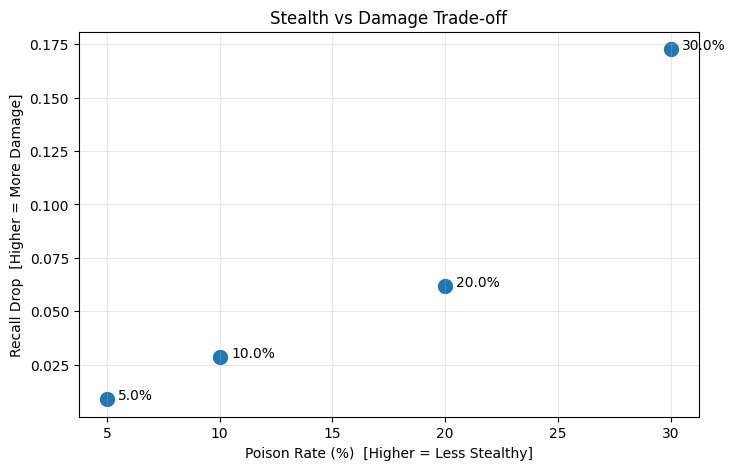

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(stealth_damage_df["Poison Rate"], stealth_damage_df["Recall Drop"], s=100)

for _, row in stealth_damage_df.iterrows():
    plt.text(row["Poison Rate"] + 0.5, row["Recall Drop"], f"{row['Poison Rate']}%")

plt.xlabel("Poison Rate (%)  [Higher = Less Stealthy]")
plt.ylabel("Recall Drop  [Higher = More Damage]")
plt.title("Stealth vs Damage Trade-off")
plt.grid(True, alpha=0.3)
plt.show()

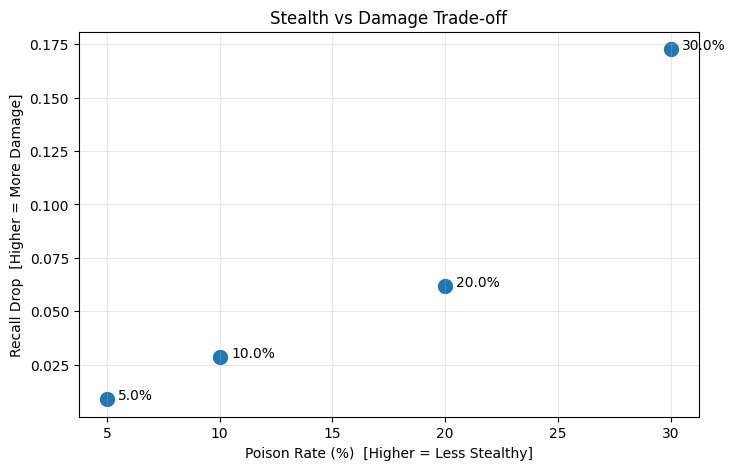

Saved figure to: ..\results\figures\stealth_vs_damage.png


In [15]:
fig_path = RESULTS_FIGURES / "stealth_vs_damage.png"

plt.figure(figsize=(8, 5))
plt.scatter(stealth_damage_df["Poison Rate"], stealth_damage_df["Recall Drop"], s=100)

for _, row in stealth_damage_df.iterrows():
    plt.text(row["Poison Rate"] + 0.5, row["Recall Drop"], f"{row['Poison Rate']}%")

plt.xlabel("Poison Rate (%)  [Higher = Less Stealthy]")
plt.ylabel("Recall Drop  [Higher = More Damage]")
plt.title("Stealth vs Damage Trade-off")
plt.grid(True, alpha=0.3)

plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv("../data/processed/elliptic_clean.csv")

X = df.drop(columns=["label", "txId"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
poison_rates = [0.05, 0.10, 0.15, 0.20, 0.25]

X_train shape: (37251, 166)
X_test shape: (9313, 166)
y_train shape: (37251,)
y_test shape: (9313,)
            Model  Poison Rate    Recall  F1 Score    PR-AUC
0   Random Forest         0.05  0.914191  0.926938  0.971220
1        AdaBoost         0.05  0.628163  0.754293  0.821758
2         XGBoost         0.05  0.947195  0.873225  0.970221
3   Random Forest         0.10  0.910891  0.921536  0.965469
4        AdaBoost         0.10  0.634763  0.753756  0.807924
5         XGBoost         0.10  0.946095  0.807891  0.959972
6   Random Forest         0.15  0.916392  0.899568  0.957319
7        AdaBoost         0.15  0.628163  0.735825  0.779459
8         XGBoost         0.15  0.948295  0.746320  0.956419
9   Random Forest         0.20  0.904290  0.878205  0.947097
10       AdaBoost         0.20  0.634763  0.740218  0.786959
11        XGBoost         0.20  0.938394  0.632086  0.937493
12  Random Forest         0.25  0.914191  0.819931  0.943684
13       AdaBoost         0.25  0.627063  0.74

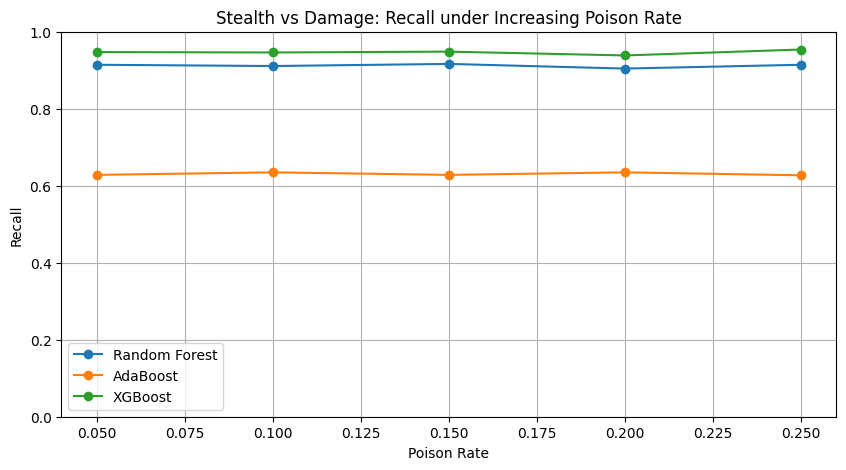

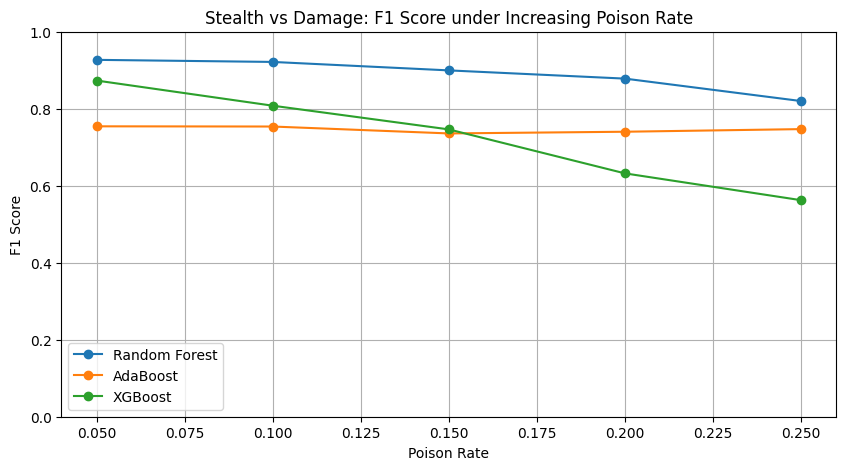

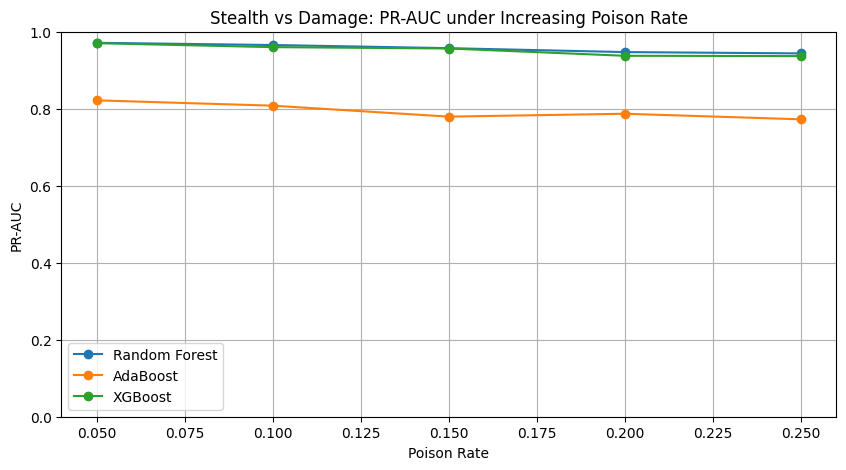

            Model  Poison Rate  Recall Drop   F1 Drop  PR-AUC Drop  \
0   Random Forest         0.05    -0.001100  0.007747     0.004191   
1   Random Forest         0.10     0.002200  0.013149     0.009942   
2   Random Forest         0.15    -0.003300  0.035117     0.018092   
3   Random Forest         0.20     0.008801  0.056480     0.028314   
4   Random Forest         0.25    -0.001100  0.114754     0.031727   
5        AdaBoost         0.05     0.006601 -0.008333     0.016925   
6        AdaBoost         0.10     0.000000 -0.007796     0.030759   
7        AdaBoost         0.15     0.006601  0.010135     0.059224   
8        AdaBoost         0.20     0.000000  0.005742     0.051723   
9        AdaBoost         0.25     0.007701 -0.001091     0.066240   
10        XGBoost         0.05     0.004400  0.066992     0.014716   
11        XGBoost         0.10     0.005501  0.132326     0.024965   
12        XGBoost         0.15     0.003300  0.193897     0.028517   
13        XGBoost   

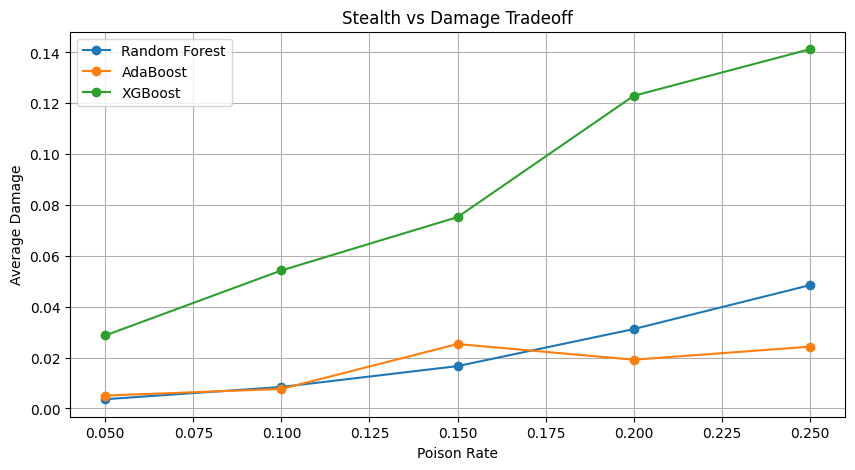


Interpretation:
- Lower poison rates are more stealthy because fewer labels are flipped.
- Higher poison rates generally cause more visible damage to model performance.
- If a model shows noticeable decline even at low poison rates, it is more vulnerable to stealthy poisoning.
- Comparing Random Forest, AdaBoost, and XGBoost helps identify which model is more robust under gradual attack intensity.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, f1_score, average_precision_score
from xgboost import XGBClassifier

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("../data/processed/elliptic_clean.csv")

X = df.drop(columns=["label", "txId"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# -----------------------------
# Poison rates
# -----------------------------
poison_rates = [0.05, 0.10, 0.15, 0.20, 0.25]

# -----------------------------
# Run stealth vs damage experiments
# -----------------------------
results = []

for poison_rate in poison_rates:
    y_train_poisoned = y_train.copy()

    n_poison = int(len(y_train_poisoned) * poison_rate)
    poison_indices = np.random.choice(y_train_poisoned.index, size=n_poison, replace=False)

    y_train_poisoned.loc[poison_indices] = 1 - y_train_poisoned.loc[poison_indices]

    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight="balanced"
    )
    rf_model.fit(X_train, y_train_poisoned)
    rf_pred = rf_model.predict(X_test)
    rf_prob = rf_model.predict_proba(X_test)[:, 1]

    rf_recall = recall_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred)
    rf_pr_auc = average_precision_score(y_test, rf_prob)

    results.append({
        "Model": "Random Forest",
        "Poison Rate": poison_rate,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "PR-AUC": rf_pr_auc
    })

    # AdaBoost
    try:
        ada_model = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )
    except TypeError:
        ada_model = AdaBoostClassifier(
            base_estimator=DecisionTreeClassifier(max_depth=1),
            n_estimators=100,
            learning_rate=0.5,
            random_state=42
        )

    ada_model.fit(X_train, y_train_poisoned)
    ada_pred = ada_model.predict(X_test)
    ada_prob = ada_model.predict_proba(X_test)[:, 1]

    ada_recall = recall_score(y_test, ada_pred)
    ada_f1 = f1_score(y_test, ada_pred)
    ada_pr_auc = average_precision_score(y_test, ada_prob)

    results.append({
        "Model": "AdaBoost",
        "Poison Rate": poison_rate,
        "Recall": ada_recall,
        "F1 Score": ada_f1,
        "PR-AUC": ada_pr_auc
    })

    # XGBoost
    scale_pos_weight = (y_train_poisoned == 0).sum() / (y_train_poisoned == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )
    xgb_model.fit(X_train, y_train_poisoned)
    xgb_pred = xgb_model.predict(X_test)
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

    xgb_recall = recall_score(y_test, xgb_pred)
    xgb_f1 = f1_score(y_test, xgb_pred)
    xgb_pr_auc = average_precision_score(y_test, xgb_prob)

    results.append({
        "Model": "XGBoost",
        "Poison Rate": poison_rate,
        "Recall": xgb_recall,
        "F1 Score": xgb_f1,
        "PR-AUC": xgb_pr_auc
    })

# -----------------------------
# Results table
# -----------------------------
stealth_damage_results = pd.DataFrame(results)
print(stealth_damage_results)

# Save results
stealth_damage_results.to_csv("../results/tables/stealth_vs_damage_results.csv", index=False)

# -----------------------------
# Plot Recall vs Poison Rate
# -----------------------------
plt.figure(figsize=(10, 5))

for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["Recall"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("Recall")
plt.title("Stealth vs Damage: Recall under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Plot F1 Score vs Poison Rate
# -----------------------------
plt.figure(figsize=(10, 5))

for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["F1 Score"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("F1 Score")
plt.title("Stealth vs Damage: F1 Score under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Plot PR-AUC vs Poison Rate
# -----------------------------
plt.figure(figsize=(10, 5))

for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["PR-AUC"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("PR-AUC")
plt.title("Stealth vs Damage: PR-AUC under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Damage calculation vs baseline
# -----------------------------
baseline_results = pd.read_csv("../results/tables/baseline_results.csv")
baseline_results["Model"] = baseline_results["Model"].astype(str).str.strip()
stealth_damage_results["Model"] = stealth_damage_results["Model"].astype(str).str.strip()

damage_rows = []

for model in ["Random Forest", "AdaBoost", "XGBoost"]:
    baseline_row = baseline_results[baseline_results["Model"] == model].iloc[0]
    model_rows = stealth_damage_results[stealth_damage_results["Model"] == model]

    for _, row in model_rows.iterrows():
        recall_drop = baseline_row["Recall"] - row["Recall"]
        f1_drop = baseline_row["F1 Score"] - row["F1 Score"]
        pr_auc_drop = baseline_row["PR-AUC"] - row["PR-AUC"]

        avg_damage = (recall_drop + f1_drop + pr_auc_drop) / 3

        damage_rows.append({
            "Model": model,
            "Poison Rate": row["Poison Rate"],
            "Recall Drop": recall_drop,
            "F1 Drop": f1_drop,
            "PR-AUC Drop": pr_auc_drop,
            "Average Damage": avg_damage
        })

damage_df = pd.DataFrame(damage_rows)
print(damage_df)

damage_df.to_csv("../results/tables/stealth_vs_damage_damage.csv", index=False)

# -----------------------------
# Plot Average Damage
# -----------------------------
plt.figure(figsize=(10, 5))

for model in damage_df["Model"].unique():
    subset = damage_df[damage_df["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["Average Damage"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("Average Damage")
plt.title("Stealth vs Damage Tradeoff")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Interpretation
# -----------------------------
print("""
Interpretation:
- Lower poison rates are more stealthy because fewer labels are flipped.
- Higher poison rates generally cause more visible damage to model performance.
- If a model shows noticeable decline even at low poison rates, it is more vulnerable to stealthy poisoning.
- Comparing Random Forest, AdaBoost, and XGBoost helps identify which model is more robust under gradual attack intensity.
""")

In [2]:
plt.savefig("../results/figures/filename.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

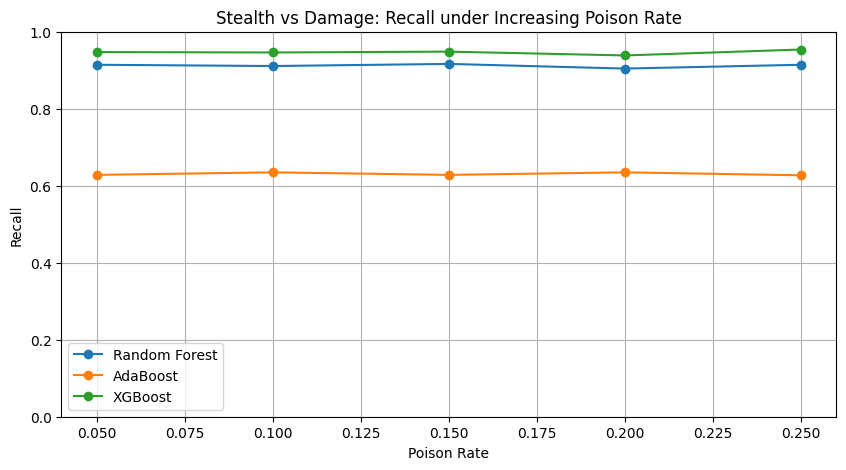

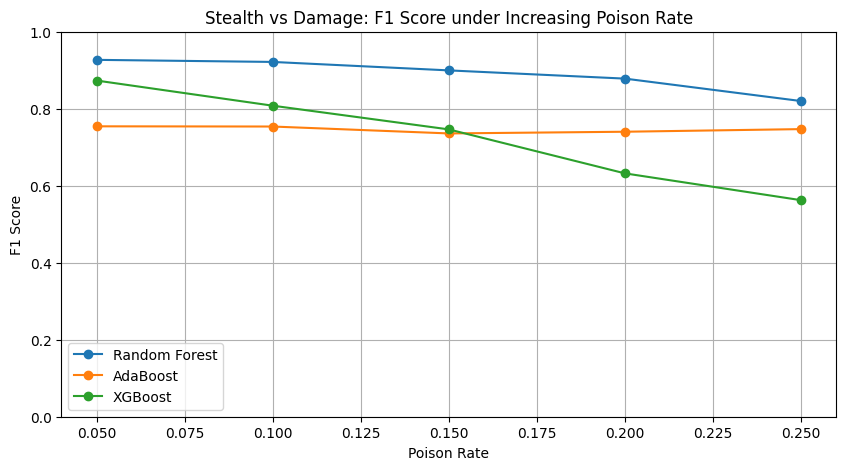

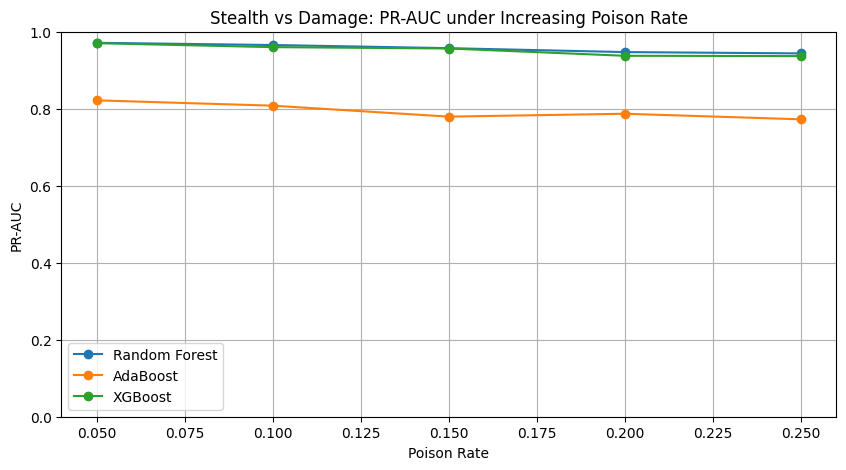

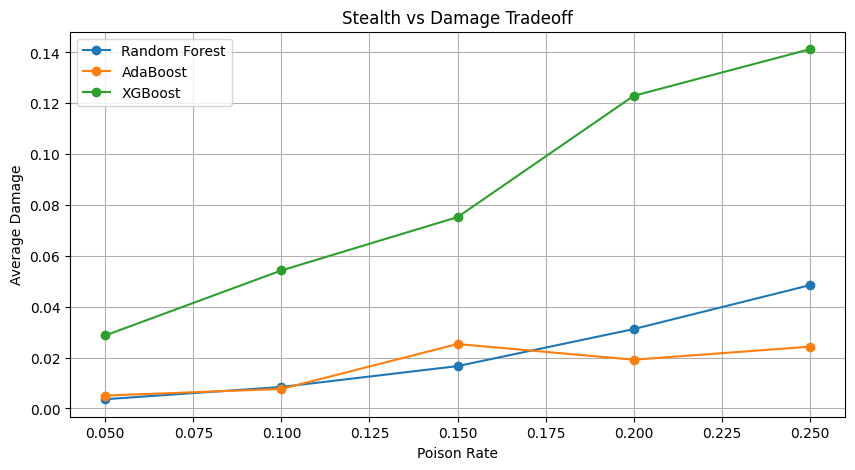

All stealth vs damage graphs saved successfully.


In [3]:
import matplotlib.pyplot as plt

# Recall graph
plt.figure(figsize=(10, 5))
for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["Recall"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("Recall")
plt.title("Stealth vs Damage: Recall under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/stealth_vs_damage_recall.png", dpi=300, bbox_inches="tight")
plt.show()

# F1 Score graph
plt.figure(figsize=(10, 5))
for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["F1 Score"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("F1 Score")
plt.title("Stealth vs Damage: F1 Score under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/stealth_vs_damage_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# PR-AUC graph
plt.figure(figsize=(10, 5))
for model in stealth_damage_results["Model"].unique():
    subset = stealth_damage_results[stealth_damage_results["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["PR-AUC"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("PR-AUC")
plt.title("Stealth vs Damage: PR-AUC under Increasing Poison Rate")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/stealth_vs_damage_pr_auc.png", dpi=300, bbox_inches="tight")
plt.show()

# Average Damage graph
plt.figure(figsize=(10, 5))
for model in damage_df["Model"].unique():
    subset = damage_df[damage_df["Model"] == model]
    plt.plot(subset["Poison Rate"], subset["Average Damage"], marker="o", label=model)

plt.xlabel("Poison Rate")
plt.ylabel("Average Damage")
plt.title("Stealth vs Damage Tradeoff")
plt.legend()
plt.grid(True)
plt.savefig("../results/figures/stealth_vs_damage_average_damage.png", dpi=300, bbox_inches="tight")
plt.show()

print("All stealth vs damage graphs saved successfully.")